<a href="https://colab.research.google.com/github/Yernar8121/Gold-Price-ML-Project/blob/main/ml_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def print_section(title):
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)
df = pd.read_csv("/content/gold_daily.csv")

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

if "Target_Next_Close" in df.columns:
    df = df.drop(columns=["Target_Next_Close"])

df["Target_Next_Close"] = df["Close"].shift(-1)
df["Target_Delta"] = df["Close"].shift(-1) - df["Close"]
df["Target_Direction"] = (df["Target_Delta"] >= 0).astype(int)

df["Naive_Next_Close"] = df["Close"]
df["Naive_Delta"] = 0
today_delta = df["Close"] - df["Close"].shift(1)
df["Naive_Direction"] = (today_delta >= 0).astype(int)

df = df.dropna().reset_index(drop=True)

FEATURES = [
    "Price_Range",
    "Open_Close_Diff",
    "High_Low_Ratio",
    "Daily_Return",
    "Close_Lag_1",
    "Close_Lag_3",
    "Close_Lag_7",
    "MA_7",
    "MA_14",
    "MA_30",
    "Volatility_7",
    "Volatility_14",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Volume",
]

features = [f for f in FEATURES if f in df.columns]

print(f"{len(features)}")
print(f"features: {features}\n")




17
features: ['Price_Range', 'Open_Close_Diff', 'High_Low_Ratio', 'Daily_Return', 'Close_Lag_1', 'Close_Lag_3', 'Close_Lag_7', 'MA_7', 'MA_14', 'MA_30', 'Volatility_7', 'Volatility_14', 'Year', 'Month', 'Day', 'DayOfWeek', 'Volume']



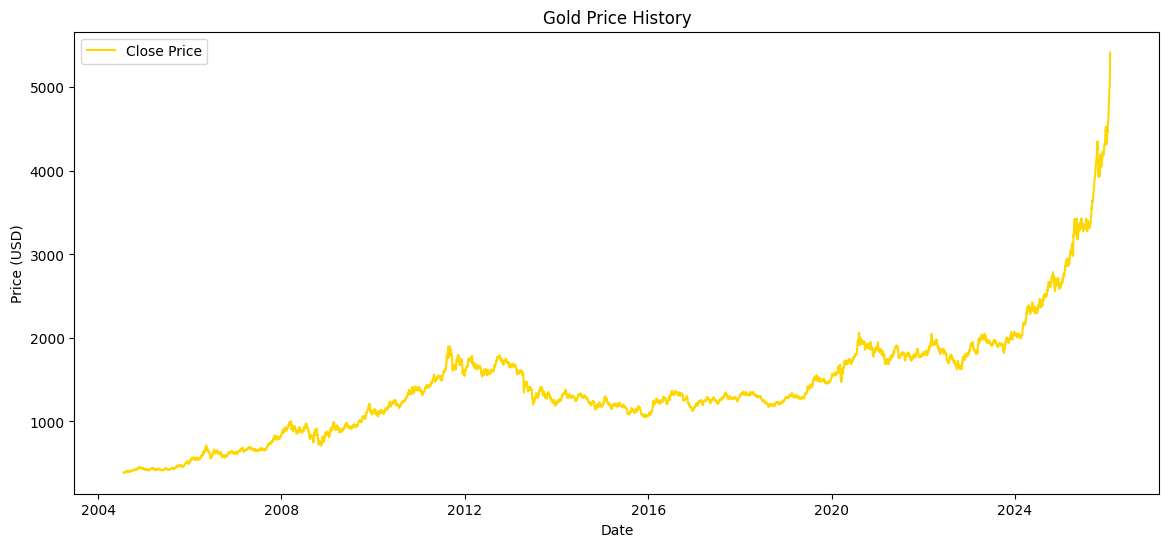

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='gold')
plt.title('Gold Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


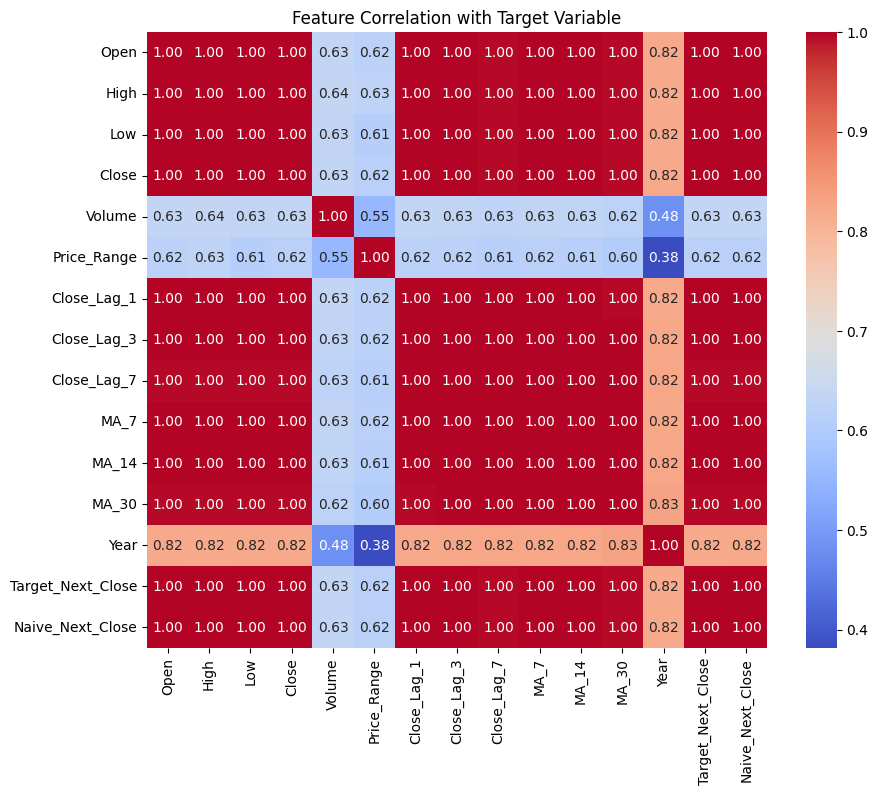

In [15]:
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)
top_corr_features = correlation.index[abs(correlation["Target_Next_Close"]) > 0.5]

sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Feature Correlation with Target Variable')
plt.show()

In [16]:
X = df[features]
y_price = df["Target_Next_Close"]
y_delta = df["Target_Delta"]
y_dir = df["Target_Direction"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

y_train_price, y_test_price = y_price.iloc[:split_idx], y_price.iloc[split_idx:]
y_train_delta, y_test_delta = y_delta.iloc[:split_idx], y_delta.iloc[split_idx:]
y_train_dir, y_test_dir = y_dir.iloc[:split_idx], y_dir.iloc[split_idx:]

naive_price = df["Naive_Next_Close"].iloc[split_idx:]
naive_delta = df["Naive_Delta"].iloc[split_idx:]
naive_dir = df["Naive_Direction"].iloc[split_idx:]

tscv = TimeSeriesSplit(n_splits=5)

print(f"Train: {len(X_train)} row |  Test: {len(X_test)} row")
print(f"Test period: {df['Date'].iloc[split_idx].date()} — {df['Date'].iloc[-1].date()}")

Train: 4400 row |  Test: 1100 row
Test period: 2021-09-15 — 2026-01-28


In [17]:
print_section("(Direction")
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])
params_lr = {
    "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}
grid_lr = GridSearchCV(pipe_lr, params_lr, cv=tscv, scoring="f1", n_jobs=-1)
grid_lr.fit(X_train, y_train_dir)
best_lr = grid_lr.best_estimator_
print(f"LR best param: {grid_lr.best_params_}")

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
params_rf_clf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}
grid_rf_clf = GridSearchCV(rf_clf, params_rf_clf, cv=tscv, scoring="f1", n_jobs=-1)
grid_rf_clf.fit(X_train, y_train_dir)
best_rf_clf = grid_rf_clf.best_estimator_
print(f"RF best param: {grid_rf_clf.best_params_}")

gb_clf = GradientBoostingClassifier(random_state=42)
params_gb_clf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}
grid_gb_clf = GridSearchCV(gb_clf, params_gb_clf, cv=tscv, scoring="f1", n_jobs=-1)
grid_gb_clf.fit(X_train, y_train_dir)
best_gb_clf = grid_gb_clf.best_estimator_
print(f"GB best param: {grid_gb_clf.best_params_}")

def clf_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-score": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

rows_clf = [
    clf_metrics("NAIVE BASELINE", y_test_dir, naive_dir),
    clf_metrics("Logistic Regression", y_test_dir, best_lr.predict(X_test)),
    clf_metrics("Random Forest", y_test_dir, best_rf_clf.predict(X_test)),
    clf_metrics("Gradient Boosting", y_test_dir, best_gb_clf.predict(X_test)),
]
res_clf = pd.DataFrame(rows_clf)
print("\n" + res_clf.to_string(index=False))

best_clf_name = res_clf.loc[res_clf["F1-score"].idxmax(), "Model"]
print(f"\best model F1: {best_clf_name}")


  (Direction
LR best param: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
RF best param: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
GB best param: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

              Model  Accuracy  Precision  F1-score
     NAIVE BASELINE    0.4709     0.5076    0.5076
Logistic Regression    0.5173     0.5427    0.5893
      Random Forest    0.5355     0.5709    0.5576
  Gradient Boosting    0.5136     0.5543    0.5167
est model F1: Logistic Regression


In [18]:
print_section("Target: Delta = Close_tomorrow - Close_today")

pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge()),
])
params_ridge = {"reg__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

grid_ridge_del = GridSearchCV(
    pipe_ridge, params_ridge, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_ridge_del.fit(X_train, y_train_delta)
best_ridge_del = grid_ridge_del.best_estimator_
print(f"Ridge best params: {grid_ridge_del.best_params_}")

rf_del = RandomForestRegressor(random_state=42, n_jobs=-1)
params_rf_del = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}
grid_rf_del = GridSearchCV(
    rf_del, params_rf_del, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_rf_del.fit(X_train, y_train_delta)
best_rf_del = grid_rf_del.best_estimator_
print(f"RF best params: {grid_rf_del.best_params_}")

gb_del = GradientBoostingRegressor(random_state=42)
params_gb_del = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}
grid_gb_del = GridSearchCV(
    gb_del, params_gb_del, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_gb_del.fit(X_train, y_train_delta)
best_gb_del = grid_gb_del.best_estimator_
print(f"GB best params: {grid_gb_del.best_params_}")

def reg_delta_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
    }

rows_del = [
    reg_delta_metrics("NAIVE BASELINE", y_test_delta, naive_delta),
    reg_delta_metrics("Ridge Regression", y_test_delta, best_ridge_del.predict(X_test)),
    reg_delta_metrics("Random Forest", y_test_delta, best_rf_del.predict(X_test)),
    reg_delta_metrics("Gradient Boosting", y_test_delta, best_gb_del.predict(X_test)),
]
res_del = pd.DataFrame(rows_del)
print("\n" + res_del.to_string(index=False))

best_del_name = res_del.loc[res_del["MAE"].idxmin(), "Model"]
print(f"\nBest model MAE: {best_del_name}")


  Target: Delta = Close_tomorrow - Close_today
Ridge best params: {'reg__alpha': 1000.0}
RF best params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
GB best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

            Model     MAE    RMSE
   NAIVE BASELINE 18.7860 34.4593
 Ridge Regression 18.9075 34.6985
    Random Forest 53.5859 75.1161
Gradient Boosting 56.9594 78.8661

Best model MAE: NAIVE BASELINE


In [19]:
print_section("Target: Next Close")
grid_ridge_price = GridSearchCV(
    pipe_ridge, params_ridge, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_ridge_price.fit(X_train, y_train_price)
best_ridge_price = grid_ridge_price.best_estimator_
print(f"Ridge best params: {grid_ridge_price.best_params_}")

grid_rf_price = GridSearchCV(
    rf_del, params_rf_del, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_rf_price.fit(X_train, y_train_price)
best_rf_price = grid_rf_price.best_estimator_
print(f"RF best params: {grid_rf_price.best_params_}")

grid_gb_price = GridSearchCV(
    gb_del, params_gb_del, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid_gb_price.fit(X_train, y_train_price)
best_gb_price = grid_gb_price.best_estimator_
print(f"GB best params: {grid_gb_price.best_params_}")

def reg_price_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE ($)": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAPE (%)": round(mape(y_true, y_pred), 4),
        "R²": round(r2_score(y_true, y_pred), 4),
    }

preds_ridge_price = best_ridge_price.predict(X_test)
preds_rf_price = best_rf_price.predict(X_test)
preds_gb_price = best_gb_price.predict(X_test)

rows_price = [
    reg_price_metrics("NAIVE BASELINE", y_test_price, naive_price),
    reg_price_metrics("Ridge Regression", y_test_price, preds_ridge_price),
    reg_price_metrics("Random Forest", y_test_price, preds_rf_price),
    reg_price_metrics("Gradient Boosting", y_test_price, preds_gb_price),
]
res_price = pd.DataFrame(rows_price)
print("\n" + res_price.to_string(index=False))

best_price_name = res_price.loc[res_price["MAE ($)"].idxmin(), "Model"]
print(f"\nBest model MAE: {best_price_name}")


  Target: Next Close
Ridge best params: {'reg__alpha': 0.01}
RF best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
GB best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}

            Model  MAE ($)  RMSE ($)  MAPE (%)      R²
   NAIVE BASELINE    18.79     34.46    0.7438  0.9977
 Ridge Regression    19.79     41.21    0.7666  0.9967
    Random Forest   460.36    811.50   14.3476 -0.2839
Gradient Boosting   453.80    804.67   14.0941 -0.2624

Best model MAE: NAIVE BASELINE


In [20]:
print_section("Conclusion")

print("Direction ]")
print(res_clf.to_string(index=False))

print("\n[Delta ($) ]")
print(res_del.to_string(index=False))

print("\n[Next Close ($) ]")
print(res_price.to_string(index=False))

print("\n────────────────────────────────────────")
print(f"Best model for Direction   → {best_clf_name}")
print(f"Best model for Delta       → {best_del_name}")
print(f"Best model for Close  → {best_price_name}")
print("────────────────────────────────────────\n")

print_section("Feature importance")

def print_feature_importance(model, feature_names, title, top_n=10):
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names)
        imp = imp.sort_values(ascending=False).head(top_n)
        print(f"\n{title}:")
        for feat, val in imp.items():
            print(f"  {feat:<22} {val:.4f}")

def get_estimator(pipeline_or_model):
    if hasattr(pipeline_or_model, "named_steps"):
        for key in ("clf", "reg"):
            if key in pipeline_or_model.named_steps:
                return pipeline_or_model.named_steps[key]
    return pipeline_or_model

print_feature_importance(get_estimator(best_rf_clf), features, "RF — Direction")
print_feature_importance(best_gb_clf, features, "GB — Direction")
print_feature_importance(get_estimator(best_rf_del), features, "RF — Delta")
print_feature_importance(best_gb_price, features, "GB — Next Close")


  Conclusion
Direction ]
              Model  Accuracy  Precision  F1-score
     NAIVE BASELINE    0.4709     0.5076    0.5076
Logistic Regression    0.5173     0.5427    0.5893
      Random Forest    0.5355     0.5709    0.5576
  Gradient Boosting    0.5136     0.5543    0.5167

[Delta ($) ]
            Model     MAE    RMSE
   NAIVE BASELINE 18.7860 34.4593
 Ridge Regression 18.9075 34.6985
    Random Forest 53.5859 75.1161
Gradient Boosting 56.9594 78.8661

[Next Close ($) ]
            Model  MAE ($)  RMSE ($)  MAPE (%)      R²
   NAIVE BASELINE    18.79     34.46    0.7438  0.9977
 Ridge Regression    19.79     41.21    0.7666  0.9967
    Random Forest   460.36    811.50   14.3476 -0.2839
Gradient Boosting   453.80    804.67   14.0941 -0.2624

────────────────────────────────────────
Best model for Direction   → Logistic Regression
Best model for Delta       → NAIVE BASELINE
Best model for Close  → NAIVE BASELINE
────────────────────────────────────────


  Feature importance

RF